<a href="https://colab.research.google.com/github/DhimanTarafdar/customer-churn-prediction/blob/main/Customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Dataset Load**

In [19]:
import pandas as pd

# load dataset
df = pd.read_csv("/content/Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# **Step 2: Basic Info**

In [20]:
print("Dataset Shape:", df.shape)

print("\nColumns:\n", df.columns)

Dataset Shape: (10000, 14)

Columns:
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')


In [21]:
# Drop unnecessary columns
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [22]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
df.shape

(10000, 11)

In [24]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [25]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


# **Step 3: One-hot Encoding**

In [26]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [27]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [28]:
df.shape

(10000, 12)

# **Step 4: Features & Labels Split**

In [29]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

# **Step 5: Train-Test Split**

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (8000, 11)
Test Shape: (2000, 11)


# **Step 6: Standardization**

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Step 7: NumPy → PyTorch Tensor Convert**

In [33]:
import torch

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# reshape target for ANN (important)
y_train_tensor = y_train_tensor.view(-1, 1)
y_test_tensor = y_test_tensor.view(-1, 1)

In [34]:
X_train_tensor

tensor([[ 0.3565, -0.6558,  0.3457,  ..., -0.5795, -0.5764,  0.9132],
        [-0.2039,  0.2949, -0.3484,  ...,  1.7257, -0.5764,  0.9132],
        [-0.9615, -1.4164, -0.6954,  ..., -0.5795,  1.7349,  0.9132],
        ...,
        [ 0.8650, -0.0854, -1.3894,  ..., -0.5795, -0.5764, -1.0950],
        [ 0.1593,  0.3900,  1.0397,  ..., -0.5795, -0.5764,  0.9132],
        [ 0.4707,  1.1506, -1.3894,  ...,  1.7257, -0.5764,  0.9132]])

# **Step 8: Check Tensor Shape**

In [35]:
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

print("X_test_tensor shape:", X_test_tensor.shape)
print("y_test_tensor shape:", y_test_tensor.shape)

X_train_tensor shape: torch.Size([8000, 11])
y_train_tensor shape: torch.Size([8000, 1])
X_test_tensor shape: torch.Size([2000, 11])
y_test_tensor shape: torch.Size([2000, 1])


# **Step 9: Custom Dataset Class**

In [72]:
from torch.utils.data import Dataset

class CustomerChurnDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.y = self.y.view(-1, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# **Step 10: Create Dataset Objects**

In [73]:

train_dataset = CustomerChurnDataset(X_train, y_train)
test_dataset = CustomerChurnDataset(X_test, y_test)

# **Step 11: DataLoader**

In [38]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Step 12: Check One Batch

In [39]:

for X_batch, y_batch in train_loader:
    print("X batch shape:", X_batch.shape)
    print("y batch shape:", y_batch.shape)
    break


X batch shape: torch.Size([32, 11])
y batch shape: torch.Size([32, 1])


# **Step 13: ANN Model using torch.nn.Module**

In [41]:
import torch
import torch.nn as nn

class ANNModel(nn.Module):
    def __init__(self, input_size):
        super(ANNModel, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 16),   # input layer → hidden layer
            nn.ReLU(),

            nn.Linear(16, 8),            # hidden layer
            nn.ReLU(),

            nn.Linear(8, 1),             # output layer
            nn.Sigmoid()                 # for binary classification
        )

    def forward(self, x):
        return self.model(x)

# **Step 14: Model Initialize**

In [42]:
input_size = X_train.shape[1]  # should be 30
model = ANNModel(input_size)

print(model)

ANNModel(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


# **Step 15: Loss Function & Optimizer Define**

In [43]:
# loss function for binary classification
criterion = nn.BCELoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# **Step 16: Set Epochs**

In [46]:
# Training configuration
epochs = 200

# **Step 17: Training Loop (Complete Pipeline)**

In [47]:
# training loop

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        # forward pass
        outputs = model(batch_features)

        # calculate loss
        loss = criterion(outputs, batch_labels)

        # clearing gradients
        optimizer.zero_grad()

        # backpropagation
        loss.backward()

        # optimizer step
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch: {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch: 10, Loss: 0.3157
Epoch: 20, Loss: 0.3153
Epoch: 30, Loss: 0.3139
Epoch: 40, Loss: 0.3142
Epoch: 50, Loss: 0.3123
Epoch: 60, Loss: 0.3123
Epoch: 70, Loss: 0.3121
Epoch: 80, Loss: 0.3114
Epoch: 90, Loss: 0.3117
Epoch: 100, Loss: 0.3110
Epoch: 110, Loss: 0.3111
Epoch: 120, Loss: 0.3093
Epoch: 130, Loss: 0.3095
Epoch: 140, Loss: 0.3100
Epoch: 150, Loss: 0.3102
Epoch: 160, Loss: 0.3096
Epoch: 170, Loss: 0.3092
Epoch: 180, Loss: 0.3092
Epoch: 190, Loss: 0.3093
Epoch: 200, Loss: 0.3083


# **Step 18: Set Model to Evaluation Mode**

In [48]:
# set model to eval mode
model.eval()

ANNModel(
  (model): Sequential(
    (0): Linear(in_features=11, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

# **Step 19: Calculate Test Accuracy**

In [49]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        # convert predictions to binary (0 or 1)
        predicted = (outputs >= 0.5).float()

        total = total + batch_labels.shape[0]

        correct = correct + (predicted == batch_labels).sum().item()

accuracy = correct / total
print(f'Test Accuracy: {accuracy:.4f}')

Test Accuracy: 0.8545


# **Step 20: Calculate Test Loss**

In [50]:
# calculate test loss
total_test_loss = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model(batch_features)

        loss = criterion(outputs, batch_labels)

        total_test_loss = total_test_loss + loss.item()

avg_test_loss = total_test_loss / len(test_loader)
print(f'Test Loss: {avg_test_loss:.4f}')

Test Loss: 0.3511


# **Modification 1: Add Another Hidden Layer**

In [60]:
# modified model with extra hidden layer
class ANNModel_Modified1(nn.Module):
    def __init__(self, input_size):
        super(ANNModel_Modified1, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 12),           # new hidden layer
            nn.ReLU(),

            nn.Linear(12, 8),
            nn.ReLU(),

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)


# **Train Modified Model 1**

In [81]:
# initialize model
model1    = ANNModel_Modified1(input_size)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model1.parameters(), lr=0.001)

# validation split
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

tr_dataset  = CustomerChurnDataset(X_tr, y_tr)
val_dataset = CustomerChurnDataset(X_val, y_val)

tr_loader  = DataLoader(tr_dataset,  batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

train_losses = []
val_losses   = []
epochs = 100

for epoch in range(epochs):

    # training
    model1.train()
    total_loss = 0
    for xb, yb in tr_loader:
        out  = model1(xb)
        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_train = total_loss / len(tr_loader)
    train_losses.append(avg_train)

    # validation
    model1.eval()
    total_val = 0
    with torch.no_grad():
        for xv, yv in val_loader:
            total_val += criterion(model1(xv), yv).item()
    avg_val = total_val / len(val_loader)
    val_losses.append(avg_val)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:3d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}')

Epoch  20 | Train: 0.3372 | Val: 0.3319
Epoch  40 | Train: 0.3290 | Val: 0.3269
Epoch  60 | Train: 0.3265 | Val: 0.3284
Epoch  80 | Train: 0.3232 | Val: 0.3355
Epoch 100 | Train: 0.3208 | Val: 0.3283


# **Evaluate Modified Model 1**

In [82]:
# set model to eval mode
model1.eval()

# calculate accuracy
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model1(batch_features)
        predicted = (outputs >= 0.5).float()

        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

accuracy2 = correct / total
print(f'Modified Model 1 - Test Accuracy: {accuracy2:.4f}')

# calculate loss
total_test_loss = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model1(batch_features)
        loss = criterion(outputs, batch_labels)

        total_test_loss = total_test_loss + loss.item()

avg_test_loss2 = total_test_loss / len(test_loader)
print(f'Modified Model 1 - Test Loss: {avg_test_loss2:.4f}')

Modified Model 1 - Test Accuracy: 0.8595
Modified Model 1 - Test Loss: 0.3438


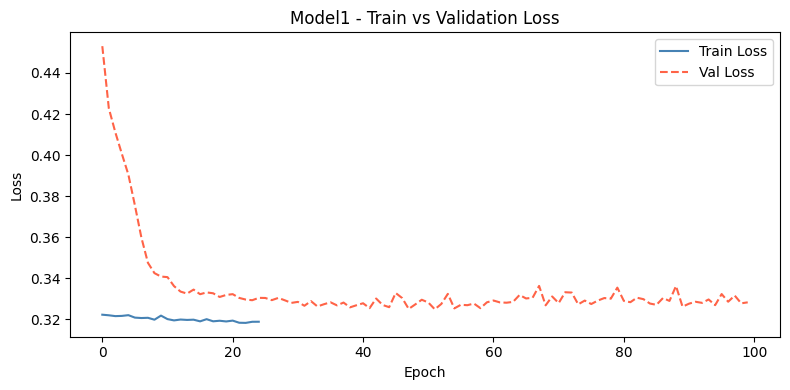

Train Loss : 0.3189
Val Loss   : 0.3283
Gap        : 0.0094
=> No Overfitting 


In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(val_losses,   label='Val Loss',   color='tomato', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model1 - Train vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

gap = val_losses[-1] - train_losses[-1]
print(f"Train Loss : {train_losses[-1]:.4f}")
print(f"Val Loss   : {val_losses[-1]:.4f}")
print(f"Gap        : {gap:.4f}")

if gap > 0.05:
    print("=> Overfitting")
else:
    print("=> No Overfitting ")

# **Modification 2: Change Activation Function**

In [68]:
# modified model with Tanh activation
class ANNModel_Modified3(nn.Module):
    def __init__(self, input_size):
        super(ANNModel_Modified3, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.Tanh(),                   # changed from ReLU to Tanh

            nn.Linear(16, 8),
            nn.Tanh(),                   # changed from ReLU to Tanh

            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

# **Train Modified Model 2**

In [69]:
# initialize model
model3 = ANNModel_Modified3(input_size)

# loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=0.001)

# training
epochs = 100

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_features, batch_labels in train_loader:

        outputs = model3(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_epoch_loss = total_epoch_loss + loss.item()

    avg_loss = total_epoch_loss / len(train_loader)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch: {epoch + 1}, Loss: {avg_loss:.4f}')

Epoch: 20, Loss: 0.3353
Epoch: 40, Loss: 0.3288
Epoch: 60, Loss: 0.3230
Epoch: 80, Loss: 0.3182
Epoch: 100, Loss: 0.3139


# **Evaluate Modified Model 2**

In [71]:
# set model to eval mode
model3.eval()

# calculate accuracy
total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model3(batch_features)
        predicted = (outputs >= 0.5).float()

        total = total + batch_labels.shape[0]
        correct = correct + (predicted == batch_labels).sum().item()

accuracy3 = correct / total
print(f'Modified Model 2 - Test Accuracy: {accuracy3:.4f}')

# calculate loss
total_test_loss = 0

with torch.no_grad():

    for batch_features, batch_labels in test_loader:

        outputs = model3(batch_features)
        loss = criterion(outputs, batch_labels)

        total_test_loss = total_test_loss + loss.item()

avg_test_loss3 = total_test_loss / len(test_loader)
print(f'Modified Model 2 - Test Loss: {avg_test_loss3:.4f}')

Modified Model 2 - Test Accuracy: 0.8615
Modified Model 2 - Test Loss: 0.3398
